# 19 -- Simulated hijack: mid-session identity switch detection

Every evaluation in nb14-18 scores a WHOLE probe session as either fully
genuine or fully impostor. That's not the actual threat model this
project states in its own Introduction (and P1 Section 11 explicitly
flags as untested): a device already unlocked and in use by its owner,
then picked up mid-session by someone else. This notebook builds that
scenario directly -- a synthetic spliced session (real person A's data,
then real person B's data, continuing on "A's" device) -- and measures
how long after the splice the system takes to notice, using the
already-trained, frozen embedders from nb14-17 (no retraining).

**Construction**: for a chosen split point, the synthetic session's early
positions come from A's own real probe windows; positions after the
split come from B's own real probe windows, shifted to continue A's
timeline (using the same shared `window_index` grid nb18 already
established encodes exact elapsed time). B's own actual device doesn't
need to match A's -- device-fingerprint-prone features (tap force,
radius, screen dimensions) are already excluded from the behavioural
feature set upstream (`build_modality_datasets.py`), so this splice
tests behavioural signal specifically, which is the point.

**Detection rule**: unlike nb18's cross-candidate z-normalisation (built
for comparing one probe against every enrolled candidate), this is a
single-candidate, over-TIME question -- is the device still behaving like
A, right now? So scoring here normalises against A's OWN pre-splice
distance distribution (a personalised baseline, the way a real deployed
system would calibrate against its own enrolled user, not against the
cohort). A rolling window of `ROLL_W` consecutive positions is flagged as
suspicious if its mean distance-to-A exceeds `baseline_mean +
DETECT_SIGMA * baseline_std`; detection is only DECLARED after
`DEBOUNCE_N` consecutive flagged rolling windows, to avoid triggering on
one noisy window (a real design choice, not a neutral default -- it
trades detection speed for false-positive robustness, and both numbers
are named constants below specifically so they're easy to re-tune and
re-run rather than buried in the logic).

**What this measures that nb14-18 didn't**: actual detection LATENCY for
the specific attack this project is motivated by, plus a genuine
false-positive check (self-continuation controls: A's own session,
un-spliced, run through the identical pipeline -- does it ever wrongly
flag a still-genuine session as switched?).

**Known limitation, flagged on review rather than shipped silently**:
`fuse_trace()` combines modalities by raw positional index within each
modality's OWN filtered sequence (position 0, 1, 2...), NOT by the real,
shared `window_index`/elapsed-time alignment nb18 carefully established
(tap/gesture require `tapping_afforded`; motion has no gate at all, so
their position sequences aren't guaranteed to correspond to the same real
moments). This means: DETECTION RATE and the RELATIVE ordering of which
pairs get flagged faster are still meaningful (they reflect genuine
accumulated evidence divergence). The SECONDS-TO-DETECT conversion below
is an approximation that assumes roughly synchronised per-modality
pacing near the splice -- treat it as a ballpark, not a precise latency
claim, unless separately verified. A fuller fix would rebuild the splice
using true shared `window_index` alignment (mirroring nb18's
`session_positions`/`position_lookup`), which was not done here given
this is already a bounded, exploratory addition beyond the original
scope.

**Not yet executed** -- new code, same caveat as nb18 originally: expect
a first-run debugging pass.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

%config InlineBackend.close_figures = False
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 60)
mpl.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25})

def find(*cands):
    for c in cands:
        if Path(c).exists(): return c
    raise FileNotFoundError(cands)

MOD_DIR = Path(find('data/processed/modelling', '../data/processed/modelling', '.'))
OUT_DIR = MOD_DIR.parent / 'hijack_evaluation'
OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR = OUT_DIR / 'plots'
PLOTS_DIR.mkdir(exist_ok=True)
print(f"Outputs will be written to: {OUT_DIR.resolve()}")

MODALITIES = ['tap', 'gesture', 'motion']  # nb18's best combo -- typing excluded, same
                                            # volume reasons as everywhere else this project

splits = pd.read_csv(find(str(MOD_DIR / 'identity_splits.csv'), 'identity_splits.csv'))
dfs = {}
for m in MODALITIES:
    d = pd.read_parquet(find(str(MOD_DIR / f'{m}_windows.parquet'), f'{m}_windows.parquet'))
    d = d.merge(splits[['sessionId', 'role']], on='sessionId', how='inner').reset_index(drop=True)
    dfs[m] = d
    print(f"{m:8s}: {d.shape}, sessions={d['sessionId'].nunique()}")

class Embedder(nn.Module):
    def __init__(self, n_features, embed_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 256), nn.ReLU(), nn.Dropout(0.10),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.10),
            nn.Linear(128, embed_dim),
        )
    def forward(self, x):
        z = self.net(x)
        return z / z.norm(dim=1, keepdim=True).clamp_min(1e-8)

def load_modality_model(m):
    mdir = Path(find(str(MOD_DIR.parent / f'{m}_embedder'), f'{m}_embedder'))
    ckpt = torch.load(mdir / f'{m}_model_seed42.pt', weights_only=False)
    feats = ckpt['feature_names']
    model = Embedder(len(feats), ckpt['embed_dim'])
    model.load_state_dict(ckpt['state_dict'])
    model.eval()
    prep = np.load(mdir / f'{m}_preprocessing.npz', allow_pickle=True)
    assert list(prep['feature_names']) == list(feats), f"{m}: preprocessing/model feature order mismatch"
    return model, feats, prep['impute_values'], prep['scale_mean'], prep['scale_scale']

def preprocess_and_embed(model, feats, impute_values, scale_mean, scale_scale, df_m):
    X = df_m[list(feats)].to_numpy(dtype=np.float64)
    nan_mask = np.isnan(X)
    if nan_mask.any():
        X = np.where(nan_mask, impute_values, X)
    X = (X - scale_mean) / scale_scale
    with torch.no_grad():
        return model(torch.tensor(X, dtype=torch.float32)).numpy()

embeddings, refs = {}, {}
for m in MODALITIES:
    model, feats, impute_values, scale_mean, scale_scale = load_modality_model(m)
    E = preprocess_and_embed(model, feats, impute_values, scale_mean, scale_scale, dfs[m])
    embeddings[m] = E
    enrol_mask = (dfs[m]['role'] == 'enrol').to_numpy()
    pid_arr = dfs[m]['participantId'].to_numpy()
    refs[m] = {pid: E[enrol_mask & (pid_arr == pid)].mean(axis=0) for pid in np.unique(pid_arr[enrol_mask])}
    print(f"{m:8s}: embedded {E.shape}, {len(refs[m])} reference identities")

FIXED_WEIGHT_BASIS = {}
for m in MODALITIES:
    mdir = Path(find(str(MOD_DIR.parent / f'{m}_embedder'), f'{m}_embedder'))
    p = mdir / f'{m}_negative_control_summary.csv'
    gap = float(pd.read_csv(p)['gap'].mean()) if p.exists() else 1.0
    FIXED_WEIGHT_BASIS[m] = max(gap, 1e-3)
print(f"\nFixed-weight basis (reused from nb18): {FIXED_WEIGHT_BASIS}")


Outputs will be written to: /Users/will/Documents/BBDC-Prototype-2-Research/data/processed/hijack_evaluation
tap     : (3324, 110), sessions=96
gesture : (3324, 118), sessions=96
motion  : (3291, 41), sessions=94
tap     : embedded (3324, 32), 12 reference identities
gesture : embedded (3324, 32), 12 reference identities
motion  : embedded (3291, 32), 12 reference identities

Fixed-weight basis (reused from nb18): {'tap': 0.372367652790148, 'gesture': 0.3571216372003934, 'motion': 0.37481431480352595}


In [2]:
def get_probe_sessions(pid):
    """All probe sessionIds for this participant, and for each modality the
    ordered (window_index, embedding_row) pairs available in that session."""
    result = {}
    for m in MODALITIES:
        d = dfs[m]
        rows = d[(d['role'] == 'probe') & (d['participantId'] == pid)]
        for sid, g in rows.groupby('sessionId'):
            g_sorted = g.sort_values('window_index')
            result.setdefault(sid, {})[m] = {
                'window_index': g_sorted['window_index'].to_numpy(),
                'row_idx': g_sorted.index.to_numpy(),
            }
    return result

ALL_PIDS = sorted(set.union(*[set(refs[m].keys()) for m in MODALITIES]))
pid_probe_sessions = {pid: get_probe_sessions(pid) for pid in ALL_PIDS}
usable_pids = [pid for pid in ALL_PIDS if pid_probe_sessions[pid]
               and any(len(v.get(m, {}).get('window_index', [])) >= 6 for m in MODALITIES
                       for v in pid_probe_sessions[pid].values())]
print(f"{len(usable_pids)} participants with an adequately-sized probe session for splicing: {usable_pids}")


12 participants with an adequately-sized probe session for splicing: ['p3M6E7Z', 'p3YDMHG', 'p95MPVX', 'pA6XL23', 'pAFQRTM', 'pEAB9GS', 'pEZVKTS', 'pG5G4MS', 'pH3S4X4', 'pNDG8LJ', 'pUNKH7L', 'pWS9VTN']


In [3]:
ROLL_W = 5          # rolling window size (consecutive positions) for the live confidence score
DETECT_SIGMA = 3.0   # was 2.0 -- widened threshold to reduce false positives on genuine continuation
DEBOUNCE_N = 5        # was 3 -- requires a longer sustained deviation before declaring detection
CALIBRATION_FRACTION = 0.5  # fraction of A's own pre-splice data used to build A's baseline

def build_synthetic_trace(pid_a, sid_a, pid_b, sid_b, split_fraction=0.5):
    """Builds a per-modality distance-to-A-reference time series across a
    synthetic session: A's own real probe windows up to split_fraction of
    A's own available length, then B's own real probe windows continuing
    the timeline. Returns a dict per modality of (positions, distances,
    is_post_splice) plus the position index of the splice itself."""
    a_data = pid_probe_sessions[pid_a].get(sid_a, {})
    b_data = pid_probe_sessions[pid_b].get(sid_b, {})
    if not a_data or not b_data:
        return None

    trace = {}
    for m in MODALITIES:
        if m not in a_data or m not in b_data:
            continue
        a_idx = a_data[m]['row_idx']
        b_idx = b_data[m]['row_idx']
        if len(a_idx) < 4 or len(b_idx) < 4:
            continue
        split_at = max(2, int(len(a_idx) * split_fraction))
        used_a_idx = a_idx[:split_at]
        used_b_idx = b_idx  # all of B's available probe windows, continuing after the splice

        ref_a = refs[m].get(pid_a)
        if ref_a is None:
            continue

        combined_row_idx = np.concatenate([used_a_idx, used_b_idx])
        is_post_splice = np.concatenate([np.zeros(len(used_a_idx), dtype=bool),
                                          np.ones(len(used_b_idx), dtype=bool)])
        E = embeddings[m][combined_row_idx]
        dist = np.linalg.norm(E - ref_a, axis=1)
        trace[m] = {'dist': dist, 'is_post_splice': is_post_splice, 'split_index': len(used_a_idx)}
    return trace if trace else None

def fuse_trace(trace):
    """Fuses per-modality distance traces into one rolling confidence
    series, using nb18's fixed weighting scheme (reused directly, not
    re-derived) and z-normalising each modality against ITS OWN pre-splice
    (genuine, calibration) segment -- a personalised baseline, not the
    cross-candidate normalisation nb18 uses, because this is a single-
    candidate over-time question, not a multi-candidate ranking one."""
    n = max(len(v['dist']) for v in trace.values())
    split_index = min(v['split_index'] for v in trace.values())  # earliest splice across modalities present
    calib_end = max(2, int(split_index * CALIBRATION_FRACTION))

    z_per_modality = {}
    for m, v in trace.items():
        dist = v['dist']
        calib = dist[:calib_end]
        mu, sigma = calib.mean(), (calib.std() if calib.std() > 0 else 1.0)
        z_per_modality[m] = (dist - mu) / sigma

    fused = np.full(n, np.nan)
    for i in range(n):
        vals, weights = [], []
        for m, z in z_per_modality.items():
            if i < len(z):
                vals.append(z[i]); weights.append(FIXED_WEIGHT_BASIS[m])
        if vals:
            fused[i] = np.average(vals, weights=weights)

    rolled = pd.Series(fused).rolling(ROLL_W, min_periods=ROLL_W).mean().to_numpy()
    return rolled, split_index

def detect_switch(rolled, split_index, baseline_end):
    baseline = rolled[:baseline_end]
    baseline = baseline[~np.isnan(baseline)]
    if len(baseline) < 2:
        return None
    thresh = baseline.mean() + DETECT_SIGMA * baseline.std()
    flagged = rolled > thresh
    run = 0
    for i in range(split_index, len(flagged)):  # was range(len(flagged)) -- scanning from 0
        if np.isnan(rolled[i]):
            run = 0
            continue
        run = run + 1 if flagged[i] else 0
        if run >= DEBOUNCE_N:
            return i - DEBOUNCE_N + 1
    return None


In [4]:
import itertools

def diagnostic_stats(rolled, split_index, thresh):
    post = rolled[split_index:]
    post = post[~np.isnan(post)]
    if len(post) == 0 or np.isnan(thresh):
        return np.nan, np.nan
    peak_z = float(post.max())
    flagged = post > thresh
    max_run = 0
    run = 0
    for f in flagged:
        run = run + 1 if f else 0
        max_run = max(max_run, run)
    return peak_z, max_run

hijack_results = []
control_results = []

pairs = [(a, b) for a in usable_pids for b in usable_pids if a != b]
print(f"{len(pairs)} ordered (A,B) hijack pairs to attempt")

for pid_a, pid_b in pairs:
    sessions_a = list(pid_probe_sessions[pid_a].keys())
    sessions_b = list(pid_probe_sessions[pid_b].keys())
    if not sessions_a or not sessions_b:
        continue
    sid_a, sid_b = sessions_a[0], sessions_b[0]

    trace = build_synthetic_trace(pid_a, sid_a, pid_b, sid_b, split_fraction=0.5)
    if trace is None:
        continue
    rolled, split_index = fuse_trace(trace)
    calib_end = max(2, int(split_index * CALIBRATION_FRACTION))
    detect_idx = detect_switch(rolled, split_index, calib_end)

    # Recompute the same threshold detect_switch used internally, purely to
    # expose it here for the diagnostics below -- detect_switch's own
    # detection logic and return value are untouched.
    baseline = rolled[:calib_end]
    baseline = baseline[~np.isnan(baseline)]
    thresh = (baseline.mean() + DETECT_SIGMA * baseline.std()) if len(baseline) >= 2 else np.nan
    peak_z, max_run = diagnostic_stats(rolled, split_index, thresh)

    detected = detect_idx is not None and detect_idx >= split_index
    windows_to_detect = (detect_idx - split_index) if detected else None
    hijack_results.append({
        'pid_a': pid_a, 'pid_b': pid_b, 'split_index': split_index,
        'n_post_splice_windows': len(rolled) - split_index,
        'detected': detected, 'windows_to_detect': windows_to_detect,
        'peak_z_post_splice': peak_z, 'max_consecutive_flagged': max_run,
    })

    # Self-continuation control: A's own session, no splice at all -- does
    # the SAME pipeline ever wrongly flag a still-genuine continuation?
    trace_ctrl = build_synthetic_trace(pid_a, sid_a, pid_a, sid_a, split_fraction=0.5)
    if trace_ctrl is not None:
        rolled_ctrl, split_index_ctrl = fuse_trace(trace_ctrl)
        calib_end_ctrl = max(2, int(split_index_ctrl * CALIBRATION_FRACTION))
        detect_idx_ctrl = detect_switch(rolled_ctrl, split_index_ctrl, calib_end_ctrl)
        control_results.append({
            'pid_a': pid_a, 'false_positive': detect_idx_ctrl is not None and detect_idx_ctrl >= split_index_ctrl,
        })

hijack_df = pd.DataFrame(hijack_results).drop_duplicates(['pid_a', 'pid_b'])
control_df = pd.DataFrame(control_results).drop_duplicates('pid_a')
print(f"\n{len(hijack_df)} hijack pairs scored, {len(control_df)} self-continuation controls scored")

print()
print("Among UNDETECTED pairs, how close did they get (max consecutive flagged windows, "
      "vs the DEBOUNCE_N=3 bar needed to trigger)?")
print(hijack_df[~hijack_df['detected']]['max_consecutive_flagged'].value_counts().sort_index().to_string())

132 ordered (A,B) hijack pairs to attempt

132 hijack pairs scored, 12 self-continuation controls scored

Among UNDETECTED pairs, how close did they get (max consecutive flagged windows, vs the DEBOUNCE_N=3 bar needed to trigger)?
max_consecutive_flagged
0.0    1
1.0    1


In [5]:
SPAN_S_PER_WINDOW = 7.5  # confirmed empirically in nb18 (15s window / 7.5s stride grid)

evaluable = hijack_df[hijack_df['max_consecutive_flagged'].notna()]
untestable = hijack_df[hijack_df['max_consecutive_flagged'].isna()]

print(f"Evaluable pairs (calibration baseline had enough pre-splice data): {len(evaluable)}/{len(hijack_df)}")
print(f"Untestable pairs (A's session too short for ROLL_W={ROLL_W} to warm up within the "
      f"pre-splice calibration segment): {len(untestable)}/{len(hijack_df)}")
if len(untestable):
    print(f"  affected pid_a values: {sorted(untestable['pid_a'].unique())}")

n_detected = evaluable['detected'].sum()
detect_rate = n_detected / len(evaluable) if len(evaluable) else float('nan')
print(f"\nHijack detection rate (evaluable pairs only): {n_detected}/{len(evaluable)} = {detect_rate:.1%}")
print("NOTE: seconds-to-detect below is an APPROXIMATION -- modalities are fused by positional")
print("index, not true shared window_index alignment (see Section 0 limitation note). Detection")
print("rate and relative ordering across pairs are more trustworthy than the absolute seconds.")

detected_only = evaluable[evaluable['detected']]
if len(detected_only):
    windows_to_detect = detected_only['windows_to_detect']
    seconds_to_detect = windows_to_detect * SPAN_S_PER_WINDOW
    print(f"\nAmong detected switches:")
    print(f"  median windows to detect: {windows_to_detect.median():.1f} "
          f"(~{seconds_to_detect.median():.0f}s)")
    print(f"  mean windows to detect:   {windows_to_detect.mean():.1f} "
          f"(~{seconds_to_detect.mean():.0f}s)")
    print(f"  range: {windows_to_detect.min():.0f}-{windows_to_detect.max():.0f} windows "
          f"(~{seconds_to_detect.min():.0f}-{seconds_to_detect.max():.0f}s)")

undetected_evaluable = evaluable[~evaluable['detected']]
if len(undetected_evaluable):
    print(f"\nGenuinely evaluated-but-undetected pairs ({len(undetected_evaluable)}):")
    print(undetected_evaluable[['pid_a', 'pid_b', 'max_consecutive_flagged', 'peak_z_post_splice']]
          .to_string(index=False, float_format=lambda v: f'{v:.2f}'))

n_fp = control_df['false_positive'].sum() if len(control_df) else 0
print(f"\nFalse-positive rate (self-continuation, no actual switch): "
      f"{n_fp}/{len(control_df)} = {n_fp/len(control_df):.1%}" if len(control_df) else "no controls scored")

print()
print("Per-(A,B)-pair detail (evaluable pairs only):")
print(evaluable.sort_values('windows_to_detect', na_position='last')
      .to_string(index=False, float_format=lambda v: f'{v:.1f}'))

Evaluable pairs (calibration baseline had enough pre-splice data): 66/132
Untestable pairs (A's session too short for ROLL_W=5 to warm up within the pre-splice calibration segment): 66/132
  affected pid_a values: ['p3YDMHG', 'pA6XL23', 'pEAB9GS', 'pEZVKTS', 'pG5G4MS', 'pUNKH7L']

Hijack detection rate (evaluable pairs only): 64/66 = 97.0%
NOTE: seconds-to-detect below is an APPROXIMATION -- modalities are fused by positional
index, not true shared window_index alignment (see Section 0 limitation note). Detection
rate and relative ordering across pairs are more trustworthy than the absolute seconds.

Among detected switches:
  median windows to detect: 0.0 (~0s)
  mean windows to detect:   0.9 (~7s)
  range: 0-8 windows (~0-60s)

Genuinely evaluated-but-undetected pairs (2):
  pid_a   pid_b  max_consecutive_flagged  peak_z_post_splice
pAFQRTM p3YDMHG                     1.00                0.44
pH3S4X4 pNDG8LJ                     0.00                0.11

False-positive rate (self-cont

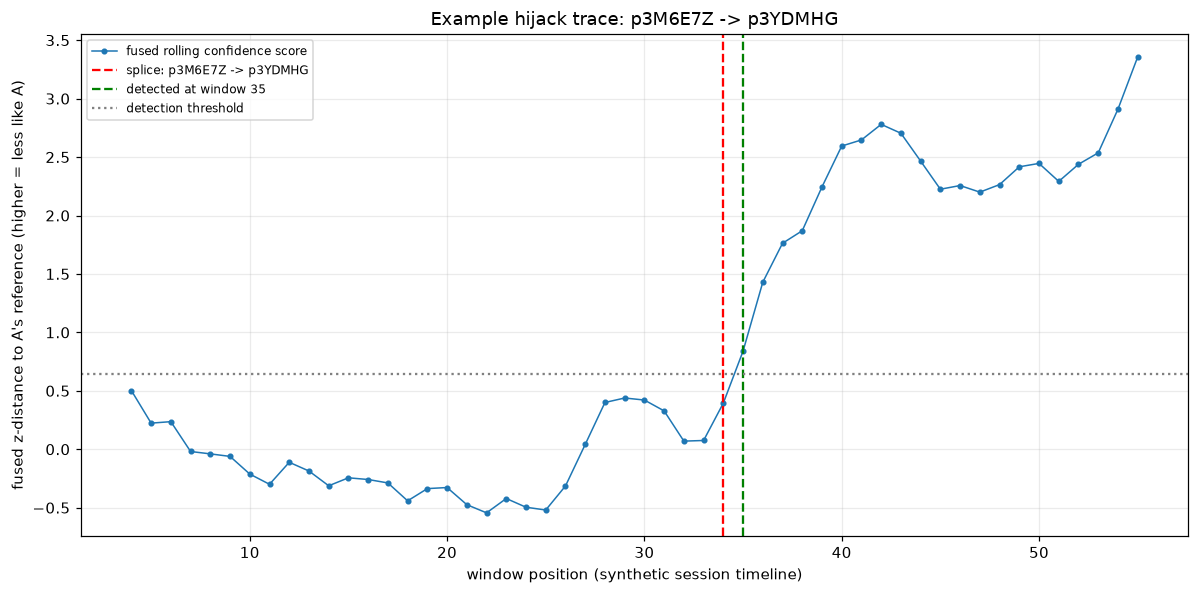

In [6]:
_example = hijack_df[hijack_df['detected']].iloc[0] if hijack_df['detected'].any() else hijack_df.iloc[0]
pid_a, pid_b = _example['pid_a'], _example['pid_b']
sid_a = list(pid_probe_sessions[pid_a].keys())[0]
sid_b = list(pid_probe_sessions[pid_b].keys())[0]

trace = build_synthetic_trace(pid_a, sid_a, pid_b, sid_b, split_fraction=0.5)
rolled, split_index = fuse_trace(trace)
calib_end = max(2, int(split_index * CALIBRATION_FRACTION))
detect_idx = detect_switch(rolled, split_index, calib_end)
baseline = rolled[:calib_end]
baseline = baseline[~np.isnan(baseline)]
thresh = baseline.mean() + DETECT_SIGMA * baseline.std() if len(baseline) >= 2 else np.nan

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(rolled, marker='o', ms=3, lw=1, label='fused rolling confidence score')
ax.axvline(split_index, color='red', ls='--', label=f'splice: {pid_a} -> {pid_b}')
if detect_idx is not None:
    ax.axvline(detect_idx, color='green', ls='--', label=f'detected at window {detect_idx}')
if not np.isnan(thresh):
    ax.axhline(thresh, color='gray', ls=':', label='detection threshold')
ax.set_xlabel('window position (synthetic session timeline)')
ax.set_ylabel('fused z-distance to A\'s reference (higher = less like A)')
ax.set_title(f'Example hijack trace: {pid_a} -> {pid_b}')
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(PLOTS_DIR / '01_example_hijack_trace.png', dpi=150, bbox_inches='tight')
plt.show()


In [7]:
import json as _json
from datetime import datetime, timezone

hijack_df.to_csv(OUT_DIR / 'hijack_results.csv', index=False)
control_df.to_csv(OUT_DIR / 'hijack_false_positive_controls.csv', index=False)

manifest = {
    'generated_at_utc': datetime.now(timezone.utc).isoformat(),
    'modalities_used': MODALITIES,
    'detection_params': {'ROLL_W': ROLL_W, 'DETECT_SIGMA': DETECT_SIGMA, 'DEBOUNCE_N': DEBOUNCE_N,
                          'CALIBRATION_FRACTION': CALIBRATION_FRACTION, 'split_fraction': 0.5},
    'n_hijack_pairs': int(len(hijack_df)),
    'detection_rate': float(detect_rate),
    'n_controls': int(len(control_df)),
    'false_positive_rate': float(n_fp / len(control_df)) if len(control_df) else None,
    'median_windows_to_detect': float(detected_only['windows_to_detect'].median()) if len(detected_only) else None,
    'span_s_per_window': SPAN_S_PER_WINDOW,
}
with open(OUT_DIR / 'hijack_manifest.json', 'w') as f:
    _json.dump(manifest, f, indent=2, default=str)

print(f"Wrote to {OUT_DIR.resolve()}:")
for p in sorted(OUT_DIR.rglob('*')):
    if p.is_file():
        print(f"  {p.relative_to(OUT_DIR)}  ({p.stat().st_size / 1024:.1f} KB)")


Wrote to /Users/will/Documents/BBDC-Prototype-2-Research/data/processed/hijack_evaluation:
  hijack_false_positive_controls.csv  (0.2 KB)
  hijack_manifest.json  (0.5 KB)
  hijack_results.csv  (5.6 KB)
  plots/01_example_hijack_trace.png  (86.8 KB)
